# Build an LLM Agent with LangGraph

## Description

This notebook shows how to build a minimal EDA-focused LLM agent with LangGraph and Claude. It demonstrates an agent that takes a prompt and autonomously selects and runs available EDA tools to complete the analysis.

## Imports

In [1]:
import logging
import os
from typing import Annotated, TypedDict

import helpers.hdbg as hdbg
import langchain_anthropic as lc_anthropic
import langchain_core.messages as lc_messages
import langchain_core.tools as lc_tools
import langgraph.graph as lg_graph
import langgraph.graph.message as lg_msg
import langgraph.prebuilt as lg_prebuilt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Config

In [2]:
# Avoid messages from Claude REST interface.
hdbg.init_logger(verbosity=logging.CRITICAL)
_LOG = logging.getLogger(__name__)

In [13]:
# Add Claude to environment variable.
os.environ["ANTHROPIC_API_KEY"] = ""
# Initiate Claude model.
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
if not ANTHROPIC_API_KEY:
    print(
        "WARNING: ANTHROPIC_API_KEY is not set. Set it in your environment before running the agent."
    )

## Generate data

In [4]:
demo_csv_path = "demo_sales.csv"
demo_df = pd.DataFrame(
    {
        "region": ["Northeast", "Midwest", "South", "West"] * 5,
        "month": list(range(1, 21)),
        "units_sold": np.random.randint(10, 500, size=20),
        "price": np.random.uniform(5.0, 30.0, size=20).round(2),
    }
)
demo_df.to_csv(demo_csv_path, index=False)
demo_df.head()

,region,month,units_sold,price
0,Northeast,1,394,13.77
1,Midwest,2,413,23.88
2,South,3,80,18.93
3,West,4,357,24.27
4,Northeast,5,477,10.45


## Define EDA tools

These tools are the agent’s abilities. We’ll expose a few for EDA:
- `read_head(path, n)`: preview top rows
- `describe_columns(path)`: numeric summary
- `groupby_agg(path, by, metric, agg)`: quick groupby summaries

In [5]:
@lc_tools.tool
def read_head(path: str, n: int = 5) -> str:
    """
    Preview the top rows of a CSV.

    :param path: path to the CSV file
    :param n: number of rows to show
    :return: table preview
    """
    df = pd.read_csv(path)
    display(df.head(n))
    return "Displayed preview."


@lc_tools.tool
def plot_histogram(path: str, column: str) -> str:
    """
    Display a histogram for a numeric column from a CSV.

    :param path: path to the CSV file
    :param column: column to plot
    :param bins: number of bins to use
    :return: confirmation message after rendering
    """
    df = pd.read_csv(path)
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    plt.figure()
    plt.hist(values, bins=20)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(f"Histogram of {column}")
    plt.tight_layout()
    plt.show()
    return "Displayed histogram."


@lc_tools.tool
def groupby_agg(path: str, by: str, metric: str) -> str:
    """
    Compute the mean of a numeric column grouped by a categorical column.

    :param path: path to the CSV file
    :param by: categorical column to group by
    :param metric: numeric column to aggregate (mean)
    :return: grouped table summary
    """
    df = pd.read_csv(path)
    grouped = df.groupby(by)[metric].mean().reset_index()
    display(grouped)
    return "Displayed grouped means."


EDA_TOOLS = [read_head, plot_histogram, groupby_agg]

## Define agent state and nodes


#############################################################################
AgentState
#############################################################################

In [6]:
class AgentState(TypedDict):
    """
    Accumulate chat messages.
    """

    messages: Annotated[list[lc_messages.AnyMessage], lg_msg.add_messages]


# Model with tools bound.
llm = lc_anthropic.ChatAnthropic(
    model="claude-3-5-sonnet-latest", temperature=0, max_tokens=1024
).bind_tools(EDA_TOOLS)


def assistant_node(state: AgentState) -> dict:
    """
    Tell me to produce the next AI message given the conversation.
    """
    ai_msg = llm.invoke(state["messages"])
    return {"messages": [ai_msg]}

In [7]:
# Tool node executes tools when the model requests them.
tools_node = lg_prebuilt.ToolNode(EDA_TOOLS)
# Build the graph.
graph = lg_graph.StateGraph(AgentState)
graph.add_node("assistant", assistant_node)
graph.add_node("tools", tools_node)
# Assistant decides either: call tools -> go to tools; or respond -> END.
graph.add_conditional_edges("assistant", lg_prebuilt.tools_condition)
graph.add_edge("tools", "assistant")
graph.set_entry_point("assistant")
app = graph.compile()
print("Graph compiled.")

Graph compiled.


## Agent Demo

In [8]:
# Define system behavior and user input.
sys_msg = lc_messages.SystemMessage(
    content=(
        "You have EDA tools for previewing rows, plotting histograms, and grouped aggregations. "
        "When a user asks for EDA, choose and call the most relevant tool. "
        "Prefer calling a tool over writing code or prose whenever a tool can do the task. "
        "After executing any tool, always append a Python code block that reproduces the exact call"
        ", include every call made this turn."
    )
)


def run_turn(user_text: str):
    state = {"messages": [sys_msg, lc_messages.HumanMessage(content=user_text)]}
    final = None
    for event in app.stream(state, stream_mode="values"):
        final = event["messages"][-1]
    return final

In [9]:
# Example 1: preview head.
final_1 = run_turn(f"Show the first 3 rows of {demo_csv_path}.")
print(final_1.content)

,region,month,units_sold,price
0,Northeast,1,394,13.77
1,Midwest,2,413,23.88
2,South,3,80,18.93


Here's the Python code to reproduce this preview:

```python
read_head(path="demo_sales.csv", n=3)
```


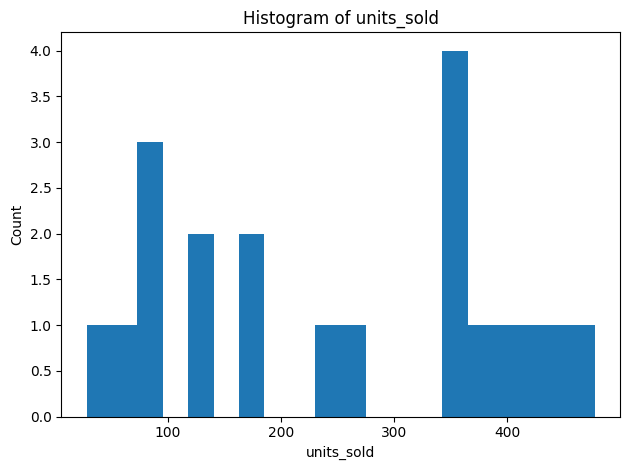

Here's the Python code to reproduce this visualization:

```python
plot_histogram(path="demo_sales.csv", column="units_sold")
```


In [10]:
# Example 2: plot histogram.
final_2 = run_turn(
    f"Plot a histogram of the 'units_sold' column from {demo_csv_path}."
)
print(final_2.content)

In [11]:
# Example 3: groupby aggregation.
final_3 = run_turn(
    f"What is the average of 'units_sold' by 'region' in {demo_csv_path}?"
)
print(final_3.content)

,region,units_sold
0,Midwest,205.6
1,Northeast,366.0
2,South,157.8
3,West,262.2


Here's the Python code to reproduce this analysis:

```python
groupby_agg(path="demo_sales.csv", by="region", metric="units_sold")
```


,region,month,units_sold,price
0,Northeast,1,394,13.77
1,Midwest,2,413,23.88
2,South,3,80,18.93
3,West,4,357,24.27
4,Northeast,5,477,10.45
5,Midwest,6,28,10.61
6,South,7,164,7.72


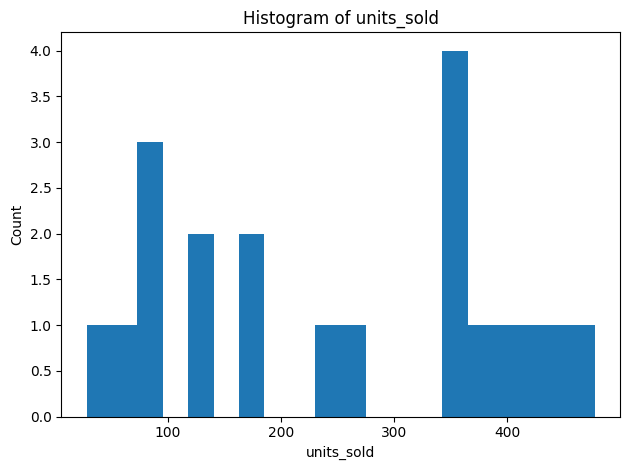

Here's the Python code to reproduce these operations:

```python
read_head(path="demo_sales.csv", n=7)
plot_histogram(path="demo_sales.csv", column="units_sold")
```


In [12]:
# Example 4: preview head and plot histogram.
final_4 = run_turn(
    f"Show the first 7 rows of {demo_csv_path}. Then, plot a histogram of the 'units_sold' column."
)
print(final_4.content)